# <center style="font-weight: bold; color: #0098cd;">Procesamiento del lenguaje natural: clasificación y estructuración de datos</center>

## 1. Introducción

### 1.1 Objetivo
transformar texto en datos estructurados útiles para análisis y modelado

👉 siguiente paso: definir **estructura exacta del JSON final + diccionario de normalización LATAM**
Ahí es donde tu TFM pasa de bueno a muy sólido.

### 1.2 Contexto dentro del sistema completo

### 1.3 Requisitos de esta fase

  * clasificación de intención
  * extracción de entidades (NER)
  * normalización

## 2. Preparación del entorno de trabajo

En esta sección se define el entorno técnico necesario para el desarrollo del pipeline de preprocesamiento de audio. Se incluyen la instalación de dependencias, la importación de librerías especializadas y la configuración de rutas de trabajo.

El objetivo es garantizar un entorno reproducible y estructurado que permita ejecutar el flujo completo de procesamiento sobre diferentes conjuntos de datos sin modificaciones en la lógica del código. Asimismo, se establece una organización clara de los directorios que facilita la separación entre datos originales, datos intermedios y resultados finales.

### 2.1 Instalación de dependencias

En este apartado se especifica la instalación de las librerías necesarias para la ejecución del *notebook*. Todas las dependencias se gestionan mediante un archivo `requirements.txt`, lo que permite replicar el entorno de ejecución de forma controlada y consistente.

#### 2.1.1 Configuración del entorno

Este notebook requiere la instalación previa de las dependencias del proyecto.

Ejecutar en terminal:

```bash
pip install -r requirements.txt
python -m spacy download es_core_news_md

### 2.2 Importación de librerías

Se importan las librerías necesarias para las distintas fases del procesamiento, incluyendo manipulación de señal, tratamiento de audio, modelos de detección de voz, análisis de datos y visualización.

Se organiza por bloques funcionales para permitir identificar claramente el propósito de cada conjunto de herramientas dentro del *pipeline*, facilitando la mantenibilidad y comprensión del código.

In [ ]:
# ==============================
# Gestión de rutas y sistema
# ==============================
from pathlib import Path                  # gestión de rutas del sistema de archivos
import json                               # lectura y escritura de ficheros JSON

# ==============================
# Manipulación de datos
# ==============================
import pandas as pd                       # manejo de datos tabulares
import numpy as np                        # operaciones numéricas

# ==============================
# Procesamiento de texto
# ==============================
import re                                 # expresiones regulares
import unicodedata                        # normalización unicode
from unidecode import unidecode           # eliminación de acentos y normalización simplificada

# ==============================
# NLP - modelos y pipelines
# ==============================
import spacy                                           # procesamiento lingüístico y NER
from transformers import AutoTokenizer, AutoModelForSequenceClassification  # modelos tipo BERT (BETO)
from sklearn.preprocessing import LabelEncoder         # codificación de etiquetas para clasificación
from sklearn.model_selection import train_test_split   # partición de datos
from sklearn.linear_model import LogisticRegression    # modelo baseline de clasificación
from sklearn.feature_extraction.text import TfidfVectorizer  # vectorización de texto con TF-IDF
from sklearn.metrics import classification_report, confusion_matrix  # evaluación de modelos

# ==============================
# Normalización y matching
# ==============================
from rapidfuzz import fuzz, process       # comparación difusa de texto (matching de términos)

# ==============================
# Utilidades y control
# ==============================
from tqdm import tqdm                     # barra de progreso
import joblib                             # guardado y carga de modelos


import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display
import torch
from transformers import Trainer, TrainingArguments, logging
import joblib
import random
from spacy.training.example import Example
from spacy.training import offsets_to_biluo_tags



/Volumes/EXTENSION/GitHub/TFM/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### 2.3 Gestión y configuración de rutas

In [167]:
# =========================
# DETECCIÓN DE RAÍZ
# =========================

project_root = Path.cwd()

while not (project_root / "data").exists():
    project_root = project_root.parent


# =========================
# DIRECTORIOS
# =========================

# Ruta raíz de datos
data_dir = project_root / "data"


# =========================
# CONFIGURACIÓN
# =========================

# Carpeta de configuración
config_dir = data_dir / "config"

# Subcarpetas de configuración
domain_config_dir = config_dir / "domain"
ner_config_dir = config_dir / "ner"
asr_config_dir = config_dir / "asr"

# Archivos de configuración
domain_terms_path = domain_config_dir / "coffee_cacao_terms.json"
ner_entities_path = ner_config_dir / "ner_entities.json"


# =========================
# DATASETS
# =========================

datasets_dir = data_dir / "datasets"
ner_dataset_dir = datasets_dir / "ner"

# Ruta correcta
ner_dataset_path = ner_dataset_dir / "ner_dataset.json"


# =========================
# TRANSCRIPCIONES (INPUT NLP)
# =========================

transcriptions_dir = data_dir / "transcriptions"

pred_asr_dir = transcriptions_dir / "asr_output"

ground_truth_dir = transcriptions_dir / "ground_truth"


# =========================
# SALIDA NLP
# =========================

structured_data_dir = data_dir / "structured_data"

classification_dir = structured_data_dir / "classification"
ner_dir = structured_data_dir / "ner"
final_output_dir = structured_data_dir / "final_output"


# =========================
# MODELOS NLP
# =========================

models_dir = data_dir / "models"

classification_model_dir = models_dir / "classification_model"
ner_model_dir = models_dir / "ner_model"


# =========================
# CREACIÓN DE CARPETAS
# =========================

# Configuración
domain_config_dir.mkdir(parents=True, exist_ok=True)
ner_config_dir.mkdir(parents=True, exist_ok=True)
asr_config_dir.mkdir(parents=True, exist_ok=True)

# Datasets
ner_dataset_dir.mkdir(parents=True, exist_ok=True)

# Salida NLP
classification_dir.mkdir(parents=True, exist_ok=True)
ner_dir.mkdir(parents=True, exist_ok=True)
final_output_dir.mkdir(parents=True, exist_ok=True)

# Modelos
classification_model_dir.mkdir(parents=True, exist_ok=True)
ner_model_dir.mkdir(parents=True, exist_ok=True)


# =========================
# VERIFICACIÓN
# =========================

print("Ruta raíz:", project_root)

print("\n--- Configuración ---")
print("Dominio:", domain_terms_path)
print("NER:", ner_entities_path)

print("\n--- Datasets ---")
print("NER dataset:", ner_dataset_path)

print("\n--- Input NLP ---")
print("Transcripciones procesadas:", pred_asr_dir)
print("Ground truth:", ground_truth_dir)

print("\n--- Output NLP ---")
print("Clasificación:", classification_dir)
print("NER:", ner_dir)
print("Salida final:", final_output_dir)

print("\n--- Modelos NLP ---")
print("Modelo clasificación:", classification_model_dir)
print("Modelo NER:", ner_model_dir)

Ruta raíz: /Volumes/EXTENSION/GitHub/TFM

--- Configuración ---
Dominio: /Volumes/EXTENSION/GitHub/TFM/data/config/domain/coffee_cacao_terms.json
NER: /Volumes/EXTENSION/GitHub/TFM/data/config/ner/ner_entities.json

--- Datasets ---
NER dataset: /Volumes/EXTENSION/GitHub/TFM/data/datasets/ner/ner_dataset.json

--- Input NLP ---
Transcripciones procesadas: /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/asr_output
Ground truth: /Volumes/EXTENSION/GitHub/TFM/data/transcriptions/ground_truth

--- Output NLP ---
Clasificación: /Volumes/EXTENSION/GitHub/TFM/data/structured_data/classification
NER: /Volumes/EXTENSION/GitHub/TFM/data/structured_data/ner
Salida final: /Volumes/EXTENSION/GitHub/TFM/data/structured_data/final_output

--- Modelos NLP ---
Modelo clasificación: /Volumes/EXTENSION/GitHub/TFM/data/models/classification_model
Modelo NER: /Volumes/EXTENSION/GitHub/TFM/data/models/ner_model


## 3. Preparación del dataset para NLP

### 3.1 Carga de transcripciones

In [35]:
# -------- ASR --------

# Carga de archivos JSON del ASR (pipeline final)
json_paths = sorted(list(pred_asr_dir.glob("*.json")))

dataset_asr = []

for path in json_paths:
    try:
        with open(path, "r", encoding="utf-8") as f:
            data = json.load(f)
        
        dataset_asr.append({
            "audio_id": data.get("audio_id", path.stem),
            "text": data.get("text", "")
        })
        
    except Exception as e:
        dataset_asr.append({
            "audio_id": path.stem,
            "text": None,
            "error": str(e)
        })

# Conversión a DataFrame
df_asr = pd.DataFrame(dataset_asr)

print(f"ASR cargado: {len(df_asr)} registros")
df_asr.head()


# -------- GROUND TRUTH --------

# Carga de anotaciones manuales
gt_path = ground_truth_dir / "ground_truth.csv"

df_gt = pd.read_csv(gt_path)

print(f"Ground truth cargado: {len(df_gt)} registros")

# Estandarización de columnas para NLP
df_gt = df_gt.rename(columns={
    "transcripcion": "text",
    "clase": "label"
})

df_gt.head()

ASR cargado: 11 registros
Ground truth cargado: 11 registros


,audio_id,text,label
0,AUDIO-2026-04-22-11-24-06,Aquí probando un minuto de audio para ver si p...,registro_inicial
1,AUDIO-2026-04-25-10-35-47,"Bueno, por lo de la vacuna no me preocupa porq...",evento_cultivo
2,AUDIO-2026-04-25-10-36-13,"Bueno es que estaba comiendo, estoy comiendo. ...",evento_cultivo
3,AUDIO-2026-04-25-10-36-43,"Hola, hola, buen día. vean que estoy regresand...",registro_inicial
4,AUDIO-2026-04-22-11-23-01,Esto es una prueba de audio a ver qué tal se c...,evento_cultivo


### 3.2 Validación de datos

#### 3.2.1 Validación del dataset ASR

In [36]:
# Texto válido: no vacío y tipo string
df_asr["text_valid"] = df_asr["text"].apply(
    lambda x: isinstance(x, str) and len(x.strip()) > 0
)

# Filtrado
valid_asr = df_asr[df_asr["text_valid"]].copy()
invalid_asr = df_asr[~df_asr["text_valid"]].copy()

print(f"ASR → válidos: {len(valid_asr)}, inválidos: {len(invalid_asr)}")

# Mostrar ejemplos inválidos si existen
if len(invalid_asr) > 0:
    print("\nEjemplos inválidos ASR:")
    display(invalid_asr.head())

ASR → válidos: 11, inválidos: 0


#### 3.2.2 Validación del *dataset Ground Truth*

In [37]:
# Texto válido
df_gt["text_valid"] = df_gt["text"].apply(
    lambda x: isinstance(x, str) and len(x.strip()) > 0
)

# Label válido (no nulo)
df_gt["label_valid"] = df_gt["label"].notnull()

# Filtrado
valid_gt = df_gt[(df_gt["text_valid"]) & (df_gt["label_valid"])].copy()
invalid_gt = df_gt[~((df_gt["text_valid"]) & (df_gt["label_valid"]))].copy()

print(f"GT → válidos: {len(valid_gt)}, inválidos: {len(invalid_gt)}")

# Mostrar ejemplos inválidos si existen
if len(invalid_gt) > 0:
    print("\nEjemplos inválidos GT:")
    display(invalid_gt.head())

GT → válidos: 11, inválidos: 0


### 3.3 Análisis inicial del *dataset Ground Truth*

In [38]:
print("Distribución de clases:")
print(valid_gt["label"].value_counts())

print("\nDistribución relativa (%):")
print((valid_gt["label"].value_counts(normalize=True) * 100).round(2))

Distribución de clases:
label
registro_inicial    6
evento_cultivo      5
Name: count, dtype: int64

Distribución relativa (%):
label
registro_inicial    54.55
evento_cultivo      45.45
Name: proportion, dtype: float64


## 4. Clasificación de mensajes (intención)

### 4.1 Definición de clases

meter algo aqui

### 4.2 Preparación del dataset

In [39]:
# Mantenemos las columnas necesarias para el modelo: identificador, texto y clase.
df_model = valid_gt[["audio_id", "text", "label"]].copy()

# Verificación del tamaño del dataset resultante
print(f"Dataset: {len(df_model)} registros")

# Inspección inicial de los datos
df_model.head()

Dataset: 11 registros


,audio_id,text,label
0,AUDIO-2026-04-22-11-24-06,Aquí probando un minuto de audio para ver si p...,registro_inicial
1,AUDIO-2026-04-25-10-35-47,"Bueno, por lo de la vacuna no me preocupa porq...",evento_cultivo
2,AUDIO-2026-04-25-10-36-13,"Bueno es que estaba comiendo, estoy comiendo. ...",evento_cultivo
3,AUDIO-2026-04-25-10-36-43,"Hola, hola, buen día. vean que estoy regresand...",registro_inicial
4,AUDIO-2026-04-22-11-23-01,Esto es una prueba de audio a ver qué tal se c...,evento_cultivo


### 4.3 Codificación de etiquetas

In [40]:
# Codificación de etiquetas a valores numéricos para el modelo
label_encoder = LabelEncoder()

df_model["label_encoded"] = label_encoder.fit_transform(df_model["label"])

label_mapping = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))

print(label_mapping)

{'evento_cultivo': np.int64(0), 'registro_inicial': np.int64(1)}


### 4.4 División del *dataset* en entrenamiento y test

In [ ]:
# División del dataset en entrenamiento y test manteniendo la distribución de clases
X = df_model["text"]
y = df_model["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y # Mantener la proporción de clases en ambos conjuntos
)

# Adaptación para modelos basados en transformers (BETO)
X_train_texts = list(X_train)
X_test_texts = list(X_test)

y_train_labels = y_train.reset_index(drop=True)
y_test_labels = y_test.reset_index(drop=True)

### 4.5 Modelado

En este apartado se aborda el modelado del problema de clasificación de mensajes a partir del texto transcrito. Para ello, se plantean dos enfoques diferenciados:
- Un modelo *baseline* basado en representaciones clásicas del texto
- Un modelo basado en transformers mediante el uso de BETO.

El modelo *baseline* se construye utilizando una representación TF-IDF de los textos junto con un clasificador de regresión logística. Esta elección responde a su eficacia contrastada en tareas de clasificación de texto, especialmente en escenarios con conjuntos de datos reducidos, donde ofrece un buen equilibrio entre rendimiento, estabilidad y coste computacional. Además, permite establecer una referencia objetiva sobre la que evaluar posteriormente el impacto del uso de modelos más complejos.

A partir de esta base, se incorpora un segundo enfoque basado en BETO, que permite capturar información contextual más rica del lenguaje. La comparación entre ambos enfoques permitirá analizar si el incremento de complejidad se traduce en una mejora real del rendimiento en el contexto del problema planteado.

#### 4.5.1 Modelo baseline (TF-IDF + *Logistic Regression*)

In [64]:
# Vectorización TF-IDF y entrenamiento del modelo baseline
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)

model_baseline = LogisticRegression(max_iter=1000)
model_baseline.fit(X_train_tfidf, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

#### 4.5.2 Modelo basado en BETO (*fine-tuning*)

##### 4.5.2.1 Carga del modelo y tokenizer

In [65]:
# Carga de tokenizer y modelo BETO para clasificación
model_name = "dccuchile/bert-base-spanish-wwm-cased"

tokenizer = AutoTokenizer.from_pretrained(model_name)

model_beto = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 51343.93it/s]
[transformers] BertForSequenceClassification LOAD REPORT from: dccuchile/bert-base-spanish-wwm-cased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
bert.pooler.dense.bias                     | MISSING    | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 
bert.pooler.dense.weight                   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from differe

##### 4.5.2.2 Preparación de los datos (tokenización)

In [66]:
# Tokenización de los textos para entrada al modelo
train_encodings = tokenizer(
    X_train_texts,
    truncation=True,
    padding=True,
    max_length=128
)

test_encodings = tokenizer(
    X_test_texts,
    truncation=True,
    padding=True,
    max_length=128
)

##### 4.5.2.3 Construcción del *dataset*

In [67]:
# Definición de dataset compatible con PyTorch
class TextDataset(torch.utils.data.Dataset):

    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item["labels"] = torch.tensor(self.labels[idx])
        return item

    def __len__(self):
        return len(self.labels)


train_dataset = TextDataset(train_encodings, y_train_labels)
test_dataset = TextDataset(test_encodings, y_test_labels)

##### 4.5.2.4 Configuración del entrenamiento

In [68]:
training_args = TrainingArguments(
    output_dir="./results",
    num_train_epochs=3,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    logging_dir="./logs",
    save_strategy="no"
)

[transformers] `logging_dir` is deprecated and will be removed in v5.2. Please set `TENSORBOARD_LOGGING_DIR` instead.


##### 4.5.2.5 Entrenamiento y *Fine-tuning* del modelo BETO

In [69]:
# Inicialización y entrenamiento del modelo
trainer = Trainer(
    model=model_beto,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset
)

trainer.train()

/Volumes/EXTENSION/GitHub/TFM/venv/lib/python3.12/site-packages/torch/utils/data/dataloader.py:752: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss


TrainOutput(global_step=6, training_loss=0.6881033579508463, metrics={'train_runtime': 4.1972, 'train_samples_per_second': 5.718, 'train_steps_per_second': 1.43, 'total_flos': 1578666332160.0, 'train_loss': 0.6881033579508463, 'epoch': 3.0})

### 4.6 Inferencia

#### 4.6.1 Inferencia con modelo *baseline*

In [70]:
# Predicción sobre el conjunto de test
y_pred = model_baseline.predict(X_test_tfidf)

#### 4.6.2 Inferencia con modelo BETO

In [71]:
# Predicción sobre el conjunto de test utilizando el modelo BETO entrenado
predictions = trainer.predict(test_dataset)

y_pred_beto = predictions.predictions.argmax(axis=1)

### 4.7 Evaluación

#### 4.7.1 Evaluación del modelo *baseline*

,precision,recall,f1-score
evento_cultivo,0.333333,1.0,0.5
registro_inicial,0.000000,0.0,0.0



Accuracy global: 0.33


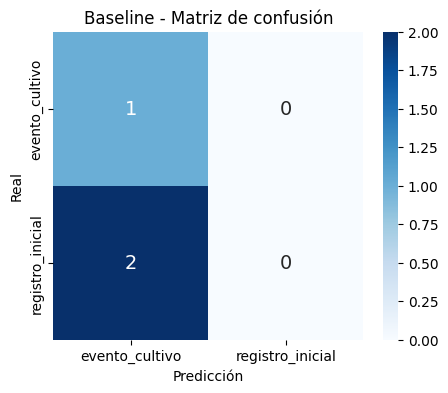

In [111]:
# Reporte como DataFrame (solo métricas por clase)
report_baseline = classification_report(
    y_test, y_pred,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics = pd.DataFrame(report_baseline).transpose().iloc[:-3, :-1]
accuracy = report_baseline["accuracy"]

# Visualización tabular
display(df_metrics)
print(f"\nAccuracy global: {accuracy:.2f}")

# Matriz de confusión (baseline - azul)
cm_baseline = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm_baseline,
            annot=True,
            fmt="d",
            cmap="Blues",
            annot_kws={"size": 14},
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("Baseline - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

#### 4.7.2 Evaluación del modelo BETO

,precision,recall,f1-score
evento_cultivo,0.333333,1.0,0.5
registro_inicial,0.000000,0.0,0.0


Accuracy global: 0.33


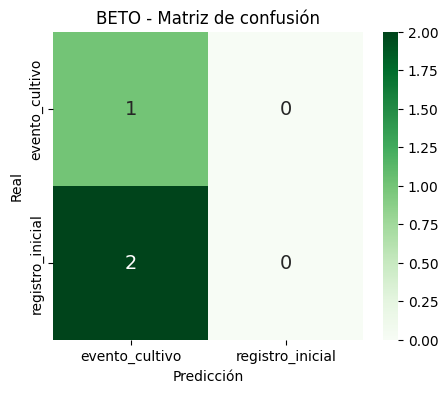

In [113]:
# Evaluación visual del modelo BETO
report_beto = classification_report(
    y_test, y_pred_beto,
    target_names=label_encoder.classes_,
    output_dict=True,
    zero_division=0
)

df_metrics_beto = pd.DataFrame(report_beto).transpose().iloc[:-3, :-1]
accuracy_beto = report_beto["accuracy"]

# Visualización tabular
display(df_metrics_beto)
print(f"Accuracy global: {accuracy_beto:.2f}")

# Matriz de confusión (BETO - verde)
cm_beto = confusion_matrix(y_test, y_pred_beto)

plt.figure(figsize=(5,4))
sns.heatmap(cm_beto,
            annot=True,
            fmt="d",
            cmap="Greens",
            annot_kws={"size": 14},
            xticklabels=label_encoder.classes_,
            yticklabels=label_encoder.classes_)
plt.title("BETO - Matriz de confusión")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

#### 4.7.3 Comparación de modelos

PONER ESTO BIEN

En este apartado se comparan los resultados obtenidos por el modelo baseline y el modelo basado en BETO, utilizando las métricas de evaluación previamente calculadas sobre el conjunto de test.

El modelo baseline, basado en TF-IDF y regresión logística, proporciona una referencia inicial del rendimiento del sistema utilizando representaciones clásicas del texto. Por su parte, el modelo BETO permite incorporar información contextual más rica mediante el uso de representaciones profundas del lenguaje.

La comparación se centra en métricas como la exactitud global y el F1-score por clase, así como en el análisis de la matriz de confusión, lo que permite identificar posibles errores sistemáticos en la clasificación.

En esta fase preliminar, los resultados deben interpretarse con cautela debido al tamaño reducido del conjunto de datos, lo que limita la capacidad de generalización de ambos modelos. No obstante, este análisis permite establecer una base metodológica sólida para evaluar el impacto del uso de modelos más complejos cuando se disponga de un volumen de datos mayor y más equilibrado.

##### 4.7.3.1 Comparación de F1 por clase

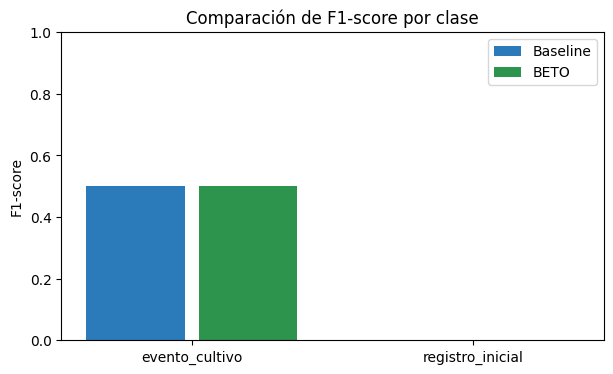

In [104]:
# Clases del problema
classes = list(label_encoder.classes_)

# Extracción de métricas F1 desde los reportes
f1_baseline = [report_baseline[c]["f1-score"] for c in classes]
f1_beto = [report_beto[c]["f1-score"] for c in classes]

# Posiciones en el eje X
x = np.arange(len(classes))
width = 0.35
gap = 0.05 # separación adicional entre barras

# Se utilizan tonos derivados de las paletas de seaborn ("Blues" y "Greens")
color_baseline = sns.color_palette("Blues")[4]
color_beto = sns.color_palette("Greens")[4]

# Construcción del gráfico de barras
plt.figure(figsize=(7,4))

plt.bar(x - width/2 - gap/2, f1_baseline, width, label="Baseline", color=color_baseline)
plt.bar(x + width/2 + gap/2, f1_beto, width, label="BETO", color=color_beto)

# Configuración de ejes y etiquetas
plt.xticks(x, classes)
plt.ylabel("F1-score")
plt.title("Comparación de F1-score por clase")
plt.ylim(0,1)

# Leyenda para identificar modelos
plt.legend()

plt.show()

Se observa que ambos modelos presentan valores similares de F1-score en las clases analizadas, sin diferencias significativas en el conjunto de prueba. La exactitud global también muestra un comportamiento equivalente entre ambos enfoques.

##### 4.7.3.2 Comparación de accuracy

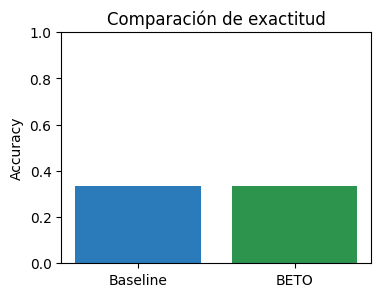

In [ ]:
# Extracción de métricas
accuracy_baseline = report_baseline["accuracy"]
accuracy_beto = report_beto["accuracy"]

# Se utilizan tonos derivados de las paletas de seaborn ("Blues" y "Greens")
color_baseline = sns.color_palette("Blues")[4]
color_beto = sns.color_palette("Greens")[4]

# Construcción del gráfico
plt.figure(figsize=(4,3))
plt.bar(
    ["Baseline", "BETO"],
    [accuracy_baseline, accuracy_beto],
    color=[color_baseline, color_beto]
)

# Configuración de ejes
plt.ylim(0,1)
plt.ylabel("Accuracy")
plt.title("Comparación de exactitud")

plt.show()

##### 4.7.3.3 Diferencia de F1

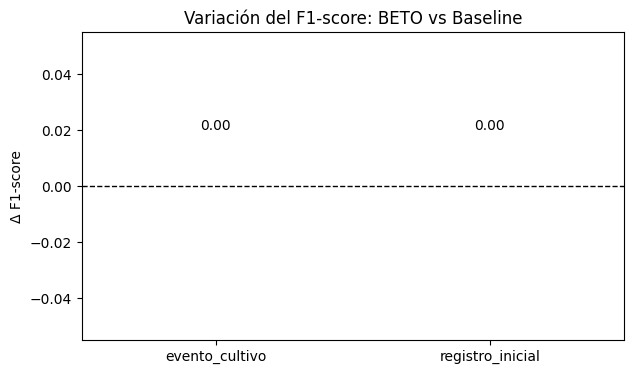

In [107]:
f1_diff = [b - a for a, b in zip(f1_baseline, f1_beto)]

# Se utilizan tonos derivados de las paletas de seaborn ("Blues" y "Greens")
color_baseline = sns.color_palette("Blues")[4]
color_beto = sns.color_palette("Greens")[4]

# Se utilizan tonos derivados de las paletas de seaborn ("Blues" y "Greens")
colors = [color_beto if v >= 0 else color_baseline for v in f1_diff]

plt.figure(figsize=(7,4))

bars = plt.bar(classes, f1_diff, color=colors)

# Línea base (sin mejora)
plt.axhline(0, color="black", linewidth=1, linestyle="--")

# Etiquetas de valores encima de cada barra
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width()/2,
        height + (0.02 if height >= 0 else -0.05),
        f"{height:.2f}",
        ha='center'
    )

# Configuración
plt.ylabel("Δ F1-score")
plt.title("Variación del F1-score: BETO vs Baseline")

plt.show()

### 4.8 Análisis final y selección del modelo óptimo

AQUI COMPLETAR CON LAS CONCLUSIONES CON LOS DATOS

Dado el tamaño reducido del dataset disponible en esta fase inicial, ambos modelos presentan un rendimiento similar, sin observarse diferencias significativas en las métricas de evaluación. Este comportamiento indica que el problema se encuentra limitado por la disponibilidad de datos, lo que impide explotar el potencial de modelos más complejos.

En este contexto, el modelo baseline basado en regresión logística se posiciona como una solución adecuada, al ofrecer un rendimiento equivalente con una menor complejidad computacional y mayor interpretabilidad.

Por otro lado, el modelo BETO, basado en arquitecturas de tipo transformer, requiere un mayor volumen de datos para capturar patrones semánticos complejos y generalizar correctamente. Su uso en esta fase se justifica como validación del pipeline y preparación para escenarios futuros.

En consecuencia, se establece como modelo operativo inicial la regresión logística, manteniendo el modelo BETO como candidato principal para futuras iteraciones del sistema, una vez se disponga de un dataset más representativo.

## 5. Optimización y configuración final del modelo seleccionado

INTRO AQUI

### 5.1 Estrategia de optimización

La optimización del modelo se plantea como un proceso sistemático de evaluación de distintas configuraciones de hiperparámetros durante el *fine-tuning* del modelo seleccionado. Dado que se parte de una arquitectura preentrenada, el objetivo no es modificar la estructura del modelo, sino ajustar su comportamiento mediante parámetros que controlan la dinámica del aprendizaje.

La estrategia adoptada consiste en una búsqueda controlada sobre un conjunto reducido de hiperparámetros clave, seleccionados por su impacto directo en el rendimiento del modelo. En particular, se consideran la tasa de aprendizaje (*learning rate*), el tamaño del lote (*batch size*), el número de épocas (*epochs*) y el parámetro de regularización (*weight decay*). Estos parámetros permiten equilibrar la velocidad de convergencia, la estabilidad del entrenamiento y la capacidad de generalización.

En lugar de emplear técnicas automatizadas de optimización, se opta por un enfoque de exploración manual mediante la evaluación de combinaciones discretas de valores. Esta decisión permite analizar de forma directa el efecto de cada hiperparámetro sobre el rendimiento del modelo, facilitando la interpretación de los resultados y manteniendo el control sobre el proceso experimental.

Para garantizar la validez de la comparación, todas las configuraciones se evalúan bajo las mismas condiciones, utilizando la misma partición de datos y las mismas métricas definidas previamente. Además, cada experimento parte de una inicialización limpia del modelo, evitando la acumulación de aprendizaje entre ejecuciones y asegurando la independencia de los resultados.

### 5.2 Definición del espacio de búsqueda

In [114]:
# Definimos los hiperparámetros a optimizar en el proceso de fine-tuning

learning_rates = [2e-5, 3e-5, 5e-5]   # Tasa de aprendizaje
batch_sizes = [4, 8]                  # Tamaño de lote
epochs_list = [2, 3, 4]               # Número de épocas
weight_decays = [0.0, 0.01, 0.1]      # Regularización L2

### 5.3 Preparación del conjunto de datos para la optimización

Con el objetivo de garantizar la independencia entre los experimentos realizados en los apartados anteriores y el proceso de optimización, se reconstruye la partición del dataset utilizando la misma semilla aleatoria, asegurando la reproducibilidad de los resultados.

#### 5.3.1 División del dataset en entrenamiento, validación y test

In [137]:
# División inicial (igual que en el apartado 4)
X = df_model["text"]
y = df_model["label_encoded"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# División adicional: train → train + validation
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

#### 5.3.2 Adaptación de los datos al formato requerido por el modelo

In [140]:
# Adaptación a formato texto
X_train_texts = list(X_train)
X_val_texts   = list(X_val)
X_test_texts  = list(X_test)

# Labels alineadas
y_train_labels = y_train.reset_index(drop=True)
y_val_labels   = y_val.reset_index(drop=True)
y_test_labels  = y_test.reset_index(drop=True)

#### 5.3.3 Tokenización de los textos

In [141]:
train_encodings = tokenizer(X_train_texts, truncation=True, padding=True, max_length=128)
val_encodings   = tokenizer(X_val_texts,   truncation=True, padding=True, max_length=128)
test_encodings  = tokenizer(X_test_texts,  truncation=True, padding=True, max_length=128)

#### 5.3.4 Construcción de los datasets para entrenamiento

In [142]:
train_dataset = TextDataset(train_encodings, y_train_labels)
val_dataset   = TextDataset(val_encodings,   y_val_labels)
test_dataset  = TextDataset(test_encodings,  y_test_labels)

### 5.3 Evaluación de combinaciones de hiperparámetros

In [ ]:
# Inicializamos estructura para almacenar resultados
results = []

# Reducimos la verbosidad de los logs para evitar saturación durante la búsqueda de hiperparámetros
logging.set_verbosity_error()

# Filtramos warning específico de PyTorch (MPS)
import warnings
warnings.filterwarnings(
    "ignore",
    message=".*pin_memory.*",
    category=UserWarning
)

# Iteramos sobre todas las combinaciones posibles de hiperparámetros
for lr in learning_rates:
    for batch_size in batch_sizes:
        for epochs in epochs_list:
            for wd in weight_decays:

                print(f"\nEntrenando con: lr={lr}, batch={batch_size}, epochs={epochs}, wd={wd}")

                # Carga del modelo desde cero
                model_beto = AutoModelForSequenceClassification.from_pretrained(
                    model_name,
                    num_labels=len(label_encoder.classes_)
                )

                # Definición de los argumentos de entrenamiento
                training_args = TrainingArguments(
                    output_dir="./results",
                    num_train_epochs=epochs,
                    per_device_train_batch_size=batch_size,
                    per_device_eval_batch_size=batch_size,
                    learning_rate=lr,
                    weight_decay=wd,
                    logging_dir="./logs",
                    save_strategy="no",
                    logging_strategy="no",
                    disable_tqdm=False
                )

                # Definición del Trainer (evaluación sobre validation)
                trainer = Trainer(
                    model=model_beto,
                    args=training_args,
                    train_dataset=train_dataset,
                    eval_dataset=val_dataset
                )

                # Entrenamiento (fine-tuning)
                trainer.train()

                # Evaluación sobre validation
                predictions = trainer.predict(val_dataset)
                y_pred = np.argmax(predictions.predictions, axis=1)

                # Métrica principal: F1 macro
                report = classification_report(
                    y_val_labels,
                    y_pred,
                    output_dict=True,
                    zero_division=0
                )

                f1_macro = report["macro avg"]["f1-score"]

                # Guardamos resultados
                results.append({
                    "learning_rate": lr,
                    "batch_size": batch_size,
                    "epochs": epochs,
                    "weight_decay": wd,
                    "f1_macro": f1_macro
                })

### 5.4 Resultados de la optimización

Se selecciona el ***F1-score macro*** como métrica principal de evaluación, ya que permite valorar el rendimiento del modelo de forma equilibrada entre las distintas clases, evitando sesgos derivados de posibles desbalances en el conjunto de datos. A diferencia de métricas globales como la exactitud, el F1-score integra tanto la precisión como el recall, proporcionando una medida más robusta del comportamiento del modelo en tareas de clasificación.

In [144]:
df_results = pd.DataFrame(results)

# Ordenamos por métrica principal
df_results_sorted = df_results.sort_values(by="f1_macro", ascending=False)

display(df_results_sorted.head())

,learning_rate,batch_size,epochs,weight_decay,f1_macro
0,0.00002,4,2,0.00,0.333333
40,0.00005,4,3,0.01,0.333333
29,0.00003,8,2,0.10,0.333333
30,0.00003,8,3,0.00,0.333333
31,0.00003,8,3,0.01,0.333333


### 5.5 Selección de la configuración óptima

* cuál es la mejor combinación
* por qué (F1_macro)

### 5.6 Evaluación final del modelo seleccionado

👉 aquí:

* reentrenas ese modelo
* evalúas en test

#### 5.6.1 Entrenamiento del modelo final

In [145]:
# Definición de los mejores hiperparámetros (ACTUALIZAR)
best_learning_rate = 2e-5      # CAMBIAR
best_batch_size = 4            # CAMBIAR
best_epochs = 2                # CAMBIAR
best_weight_decay = 0.0        # CAMBIAR

# Carga del modelo
model_beto_final = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=len(label_encoder.classes_)
)

# Argumentos de entrenamiento
training_args_final = TrainingArguments(
    output_dir="./results_final",
    num_train_epochs=best_epochs,
    per_device_train_batch_size=best_batch_size,
    per_device_eval_batch_size=best_batch_size,
    learning_rate=best_learning_rate,
    weight_decay=best_weight_decay,
    save_strategy="no",
    logging_strategy="no",
    disable_tqdm=False
)

# Trainer
trainer_final = Trainer(
    model=model_beto_final,
    args=training_args_final,
    train_dataset=train_dataset,
    eval_dataset=val_dataset
)

# Entrenamiento
trainer_final.train()

Loading weights: 100%|██████████| 197/197 [00:00<00:00, 40027.03it/s]


Step,Training Loss


TrainOutput(global_step=4, training_loss=0.6269528269767761, metrics={'train_runtime': 2.8808, 'train_samples_per_second': 4.165, 'train_steps_per_second': 1.388, 'total_flos': 789333166080.0, 'train_loss': 0.6269528269767761, 'epoch': 2.0})

#### 5.6.2 Evaluación final en el conjunto de test

In [146]:
# Predicciones en test
predictions_test = trainer_final.predict(test_dataset)
y_pred_test = np.argmax(predictions_test.predictions, axis=1)

# Métricas
report_test = classification_report(
    y_test_labels,
    y_pred_test,
    target_names=label_encoder.classes_,
    digits=4
)

print("Resultados finales en test:")
print(report_test)

Resultados finales en test:
                  precision    recall  f1-score   support

  evento_cultivo     1.0000    1.0000    1.0000         1
registro_inicial     1.0000    1.0000    1.0000         2

        accuracy                         1.0000         3
       macro avg     1.0000    1.0000    1.0000         3
    weighted avg     1.0000    1.0000    1.0000         3



#### 5.6.3 Visualización de resultados

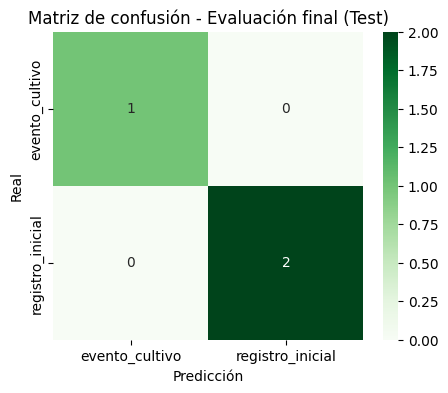

In [147]:
# Matriz de confusión
cm_test = confusion_matrix(y_test_labels, y_pred_test)

plt.figure(figsize=(5,4))
sns.heatmap(
    cm_test,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title("Matriz de confusión - Evaluación final (Test)")
plt.xlabel("Predicción")
plt.ylabel("Real")
plt.show()

#### 5.6.4 Interpretación de resultados y validación del modelo

CONCLUSIONES AQUI

meter tambien: Consideraciones sobre generalización

👉 aquí ganas puntos:

* riesgo de sobreajuste
* dependencia del tamaño del dataset

### 5.7 Preparación para integración en *pipeline*

EXPLICACIÓN AQUI

In [151]:
# Guardado del modelo de clasificación
trainer_final.save_model(classification_model_dir)

# Guardado del tokenizer asociado
tokenizer.save_pretrained(classification_model_dir)

# Guardado del codificador de etiquetas
joblib.dump(label_encoder, classification_model_dir / "label_encoder.pkl")

Writing model shards: 100%|██████████| 1/1 [00:01<00:00,  1.64s/it]


['/Volumes/EXTENSION/GitHub/TFM/data/models/classification_model/label_encoder.pkl']

## CUIDADO AL GUARDAR, OCUPA MUCHO PARA GITHUB

## 6. Extracción de entidades (NER)

### 6.1 Validación de la alineación de entidades (*offsets*)

Antes de proceder al entrenamiento del modelo, se realiza una validación del dataset anotado con el objetivo de comprobar la correcta alineación de las entidades definidas mediante offsets.

Este proceso permite detectar errores en los índices de inicio y fin de cada entidad, los cuales deben coincidir exactamente con los límites de los *tokens* generados por spaCy. En caso contrario, dichas entidades serán ignoradas durante el entrenamiento, afectando negativamente al rendimiento del modelo.

Para ello, se emplea la función `offsets_to_biluo_tags`, que permite verificar la correspondencia entre las anotaciones y la tokenización del texto.

<div style="border-left: 5px solid #ff4d4d; padding: 10px; background-color: #2b2b2b; color: #f0f0f0;">
<strong style="color: red">⚠️ Advertencia:</strong> Se recomienda ejecutar este bloque tras cualquier modificación del *dataset* antes de proceder al entrenamiento del modelo.
</div>

In [209]:
# Carga del archivo de entidades NER
with open(ner_dataset_path, "r", encoding="utf-8") as f:
    ner_data_raw = json.load(f)

errores = []

for i, item in enumerate(ner_data_raw):
    text = item["text"]
    entities = [(ent["start"], ent["end"], ent["label"]) for ent in item["entities"]]

    doc = nlp.make_doc(text)
    tags = offsets_to_biluo_tags(doc, entities)

    if "-" in tags:
        errores.append({
            "index": i,
            "text": text,
            "entities": entities,
            "tags": tags
        })

# Resultado
print(f"Errores encontrados: {len(errores)}")

for e in errores:
    print("\n---")
    print("Index:", e["index"])
    print("Texto:", e["text"])
    print("Entidades:", e["entities"])
    print("Tags:", e["tags"])

Errores encontrados: 2

---
Index: 2
Texto: La semana pasada encontré broca en el cafeto
Entidades: [(3, 16, 'fecha_evento'), (21, 30, 'accion'), (31, 36, 'problema'), (43, 49, 'cultivo')]
Tags: ['O', 'B-fecha_evento', 'L-fecha_evento', '-', '-', '-', '-', '-']

---
Index: 4
Texto: Apliqué fertilizante en el lote 3 del café
Entidades: [(0, 7, 'accion'), (8, 21, 'producto'), (25, 31, 'ubicacion'), (36, 40, 'cultivo')]
Tags: ['U-accion', '-', 'O', '-', '-', 'O', '-', '-']


### 6.2 Definición de entidades

In [210]:
# Carga del archivo de entidades NER
with open(ner_entities_path, "r", encoding="utf-8") as f:
    ner_config = json.load(f)

# Lista de entidades definidas
entities = ner_config["entities"]

# Verificación
print("Entidades definidas para NER:")
print(entities)

Entidades definidas para NER:
['cultivo', 'problema', 'accion', 'producto', 'cantidad', 'fecha_evento']


### 6.3 Preparación del dataset

In [211]:
# Ruta correcta
ner_dataset_path = data_dir / "datasets" / "ner" / "ner_dataset.json"

# Carga del dataset
with open(ner_dataset_path, "r", encoding="utf-8") as f:
    ner_data_raw = json.load(f)

# Conversión a formato spaCy
train_data = []

for item in ner_data_raw:
    text = item["text"]
    entities = [(ent["start"], ent["end"], ent["label"]) for ent in item["entities"]]
    train_data.append((text, {"entities": entities}))

print("Número de ejemplos:", len(train_data))

Número de ejemplos: 5


### 6.4 Implementación del modelo NER

In [212]:
# Carga modelo base en español
nlp = spacy.load("es_core_news_md")

### 6.5 *Fine-tuning* del modelo NER basado en spaCy

In [213]:
# SEMILLA (reproducibilidad)
random.seed(42)
np.random.seed(42)
spacy.util.fix_random_seed(42)


# CONFIGURACIONES (grid)
results = []

configs = [
    {"n_iter": n, "drop": d}
    for n in [10, 20, 30]
    for d in [0.2, 0.3, 0.4]
]


# ENTRENAMIENTO
for config in configs:

    print("\nEntrenando config:", config)

    # Reiniciar modelo (CRÍTICO)
    nlp = spacy.load("es_core_news_md")
    ner = nlp.get_pipe("ner")

    # Añadir etiquetas
    for _, annotations in train_data:
        for ent in annotations["entities"]:
            ner.add_label(ent[2])

    optimizer = nlp.resume_training()

    best_loss = float("inf")
    patience = 3
    no_improve = 0
    epochs_run = 0

    for epoch in range(config["n_iter"]):

        random.shuffle(train_data)
        losses = {}

        for text, annotations in train_data:
            doc = nlp.make_doc(text)
            example = Example.from_dict(doc, annotations)

            nlp.update(
                [example],
                drop=config["drop"],
                losses=losses
            )

        current_loss = losses.get("ner", 0.0)
        epochs_run += 1

        # Early stopping
        if current_loss < best_loss:
            best_loss = current_loss
            no_improve = 0
        else:
            no_improve += 1

        if no_improve >= patience:
            print("Early stopping activado")
            break

    # Guardar resultado
    results.append({
        "n_iter": config["n_iter"],
        "drop": config["drop"],
        "epochs_run": epochs_run,
        "final_loss": best_loss
    })


Entrenando config: {'n_iter': 10, 'drop': 0.2}

Entrenando config: {'n_iter': 10, 'drop': 0.3}

Entrenando config: {'n_iter': 10, 'drop': 0.4}

Entrenando config: {'n_iter': 20, 'drop': 0.2}

Entrenando config: {'n_iter': 20, 'drop': 0.3}

Entrenando config: {'n_iter': 20, 'drop': 0.4}

Entrenando config: {'n_iter': 30, 'drop': 0.2}
Early stopping activado

Entrenando config: {'n_iter': 30, 'drop': 0.3}
Early stopping activado

Entrenando config: {'n_iter': 30, 'drop': 0.4}
Early stopping activado


### 6.6 Análisis de resultados del *fine-tuning*

In [214]:
df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values(by="final_loss")

display(df_results_sorted)

,n_iter,drop,epochs_run,final_loss
3,20,0.2,20,2.276559
6,30,0.2,22,2.363305
4,20,0.3,20,2.628853
7,30,0.3,21,3.191957
5,20,0.4,20,3.791928
0,10,0.2,10,9.138311
1,10,0.3,10,12.346478
2,10,0.4,10,13.300011
8,30,0.4,10,14.430601


aqui comentamos y elegimos la mejor

### 6.7 Entrenamiento final del modelo NER tras selección de configuración óptima

In [216]:
# SEMILLA (reproducibilidad)
random.seed(42)
np.random.seed(42)
spacy.util.fix_random_seed(42)


# Selección de la mejor configuración
best_config = df_results_sorted.iloc[0].to_dict()
print("Mejor configuración:", best_config)


# =========================
# ENTRENAMIENTO FINAL
# =========================

# Carga modelo base
nlp = spacy.load("es_core_news_md")
ner = nlp.get_pipe("ner")

# Añadir etiquetas del dataset
for _, annotations in train_data:
    for ent in annotations["entities"]:
        ner.add_label(ent[2])

# Inicializar optimizador
optimizer = nlp.resume_training()



# Configuración de early stopping
best_loss = float("inf")
patience = 3
no_improve = 0


# =========================
# BUCLE DE ENTRENAMIENTO
# =========================

for epoch in range(int(best_config["n_iter"])):

    random.shuffle(train_data)
    losses = {}

    for text, annotations in train_data:

        doc = nlp.make_doc(text)
        example = Example.from_dict(doc, annotations)

        nlp.update(
            [example],
            drop=best_config["drop"],
            losses=losses
        )

    current_loss = losses.get("ner", 0.0)

    print(f"Epoch {epoch+1} - Loss: {current_loss}")

    # Early stopping: mejora del modelo
    if current_loss < best_loss:
        best_loss = current_loss
        no_improve = 0
    else:
        # Early stopping: no mejora acumulada
        no_improve += 1

    # Early stopping: condición de parada
    if no_improve >= patience:
        print("Early stopping activado")
        break

Mejor configuración: {'n_iter': 20.0, 'drop': 0.2, 'epochs_run': 20.0, 'final_loss': 2.2765586376190186}
Epoch 1 - Loss: 25.777006149291992
Epoch 2 - Loss: 21.8566951751709
Epoch 3 - Loss: 21.46005630493164
Epoch 4 - Loss: 18.661958694458008
Epoch 5 - Loss: 16.285289764404297
Epoch 6 - Loss: 14.961421966552734
Epoch 7 - Loss: 14.362088203430176
Epoch 8 - Loss: 12.434358596801758
Epoch 9 - Loss: 11.455564498901367
Epoch 10 - Loss: 9.283023834228516
Epoch 11 - Loss: 8.376096725463867
Epoch 12 - Loss: 6.466289043426514
Epoch 13 - Loss: 5.683686256408691
Epoch 14 - Loss: 3.9829025268554688
Epoch 15 - Loss: 3.254910469055176
Epoch 16 - Loss: 3.558223247528076
Epoch 17 - Loss: 10.545735359191895
Epoch 18 - Loss: 2.5700557231903076
Epoch 19 - Loss: 8.23058032989502
Epoch 20 - Loss: 11.746109962463379


### 6.8 Guardado del modelo

### 6.9 Ejemplo de inferencia

In [ ]:
def extract_entities(text):
    doc = nlp(text)
    return [(ent.text, ent.label_) for ent in doc.ents]


# Prueba
texto = "La semana pasada encontré broca en el cafeto"
print(extract_entities(texto))

[('Ayer', 'fecha_evento'), ('fumigué', 'accion'), ('café', 'cultivo')]


### 6.6 Evaluación

* precisión, recall, F1
* análisis de errores

### 6.6 Preparación para *pipeline*

In [ ]:
# Guardado del modelo NER
nlp.to_disk(ner_model_dir)

print("Modelo NER guardado en:", ner_model_dir)

## 7. Normalización de entidades (clave)

### 7.1 Problema

* variabilidad lingüística (LATAM)

### 7.2 Estrategia

* diccionario de sinónimos
* reglas de normalización

Ejemplo:

```text
abono / fertilizante → fertilizante
```

### 7.3 Aplicación

* transformación de entidades a formato estándar

## 8. Integración del pipeline

```text
texto → clasificación → NER → normalización → datos estructurados
```

* uso de la clase para guiar extracción

## 9. Generación de output final

```json
{
  "audio_id": "...",
  "user_id": "...",
  "transcription": "...",
  "clasificacion": "evento_cultivo",
  "entidades": {
    "accion": "...",
    "producto": "...",
    "cantidad": "...",
    "problema": "..."
  },
  "processing_version": "v1"
}
```

## 10. Análisis global de resultados

* distribución de clases
* calidad de entidades
* errores frecuentes

## 11. Selección del pipeline final

* justificación de:

  * modelo clasificación
  * modelo NER
  * reglas de normalización

## 12. Implementación y ejecución global PLN

### 6.1 Inicialización del entorno y gestión de rutas

### 6.2 Implementación de funciones del pipeline de clasificación

#### 6.2.1 Carga del dataset de transcripciones

In [ ]:
# Carga del dataset de transcripciones
df_transcriptions = pd.read_json("ruta_a_transcripciones.json")

df_transcriptions.head()

#### 6.2.2 Inicialización del modelo de clasificación

In [ ]:
# Carga del modelo BETO
model_beto_final = AutoModelForSequenceClassification.from_pretrained("ruta_modelo_final")

tokenizer = AutoTokenizer.from_pretrained(model_name)

#### 6.2.3 Clasificación de mensajes

In [ ]:
# Función de clasificación
def classify_text(text):
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    )

    outputs = model_beto_final(**inputs)
    logits = outputs.logits
    pred = torch.argmax(logits, dim=1).item()

    return label_encoder.inverse_transform([pred])[0]

#### 6.2.4 Generación de salida estructurada

In [ ]:
# Generación de salida estructurada
def process_classification(text):
    classification = classify_text(text)

    return {
        "text": text,
        "classification": classification
    }

### 6.3 Ejecución del *pipeline* de clasificación

### 6.4 Validación del *pipeline* de clasificación

## 11. Conclusiones
- Resumen del proceso aplicado
- Resultados principales
- Relevancia para el pipeline de Speech-to-Text

Te las defino, pero ojo: si no las acotas bien ahora, luego tendrás ruido y dataset inútil.

Voy a darte un **esquema mínimo pero sólido**, orientado a tu objetivo (modelo posterior).

---

# **Definición de entidades (NER) — Notebook 3**

## 🎯 Objetivo

Extraer información estructurada de los audios para construir un dataset útil para análisis y modelos predictivos.

---

## ✅ 1. Entidades de contexto (registro inicial)

Estas definen la “foto base” del productor:

* `cultivo` → café, cacao, maíz…
* `variedad` → arábica, robusta… (si aparece)
* `ubicacion` → finca, zona, comunidad
* `superficie` → hectáreas / extensión
* `edad_cultivo` → años / meses
* `sistema_produccion` → orgánico, convencional (si aplica)

---

## ✅ 2. Entidades de evento (núcleo del sistema)

Aquí está el valor real.

### 🔹 Acción

* `accion` → fertilización, riego, poda, fumigación, siembra, cosecha

### 🔹 Producto / insumo

* `producto` → urea, fungicida, abono, herbicida

### 🔹 Problema

* `problema` → plaga, enfermedad, sequía, exceso de lluvia

### 🔹 Cantidad

* `cantidad` → “2 sacos”, “5 litros”

### 🔹 Fecha / tiempo

* `fecha_evento` → ayer, hoy, hace 3 días

### 🔹 Estado del cultivo

* `estado` → bueno, malo, afectado, creciendo

---

## ✅ 3. Entidades ambientales (muy importantes)

* `clima` → lluvia, calor, sequía
* `condicion_suelo` → húmedo, seco (si aparece)

---

## ✅ 4. Entidades auxiliares (opcionales pero útiles)

* `frecuencia` → cada semana, una vez al mes
* `intensidad` → mucho, poco
* `observacion` → texto libre relevante

---

# 🧠 Ejemplo real

Audio:

> “ayer eché dos sacos de urea porque vi una plaga”

Salida:

```json
{
  "accion": "fertilizacion",
  "producto": "urea",
  "cantidad": "2 sacos",
  "fecha_evento": "ayer",
  "problema": "plaga"
}
```

